# Белякова Екатерина 636-01
Тема: **Исследование методов машинного обучения для прогнозирования сахарного диабета на основе клинических даннных**.

Целью проекта является исследование открытого набора данных данных из датасета Diabetes Prediction Dataset, которвый был выбран в Kaggle https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

Целевая переменная diabetes
0- диабета нет, 1- диабет есть

## Предобработка и импорт данных


In [28]:
import os
os.environ['MPLCONFIGDIR'] = os.path.join(os.getcwd(), '.matplotlib')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## Загрузка данных


In [29]:
diabetes = pd.read_csv('diabetes_prediction_dataset.csv')
diabetes.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## Проверка данных

Узнаю количество строк и столбцов

In [30]:
diabetes.shape

(100000, 9)

В датасете 100000 строк и 9 столбцов.
Признаки

In [31]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


Выведу азнвания признаков

In [32]:
diabetes.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

Посмотрю описательную статистику числовых признаков

In [33]:
diabetes.describe().round(2)

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,41.89,0.07,0.04,27.32,5.53,138.06,0.08
std,22.52,0.26,0.19,6.64,1.07,40.71,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.63,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,60.00,0.00,0.00,29.58,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00


Посмотрю описательную статистику категориальных признаков

In [34]:
diabetes.describe(include='object').T

,count,unique,top,freq
gender,100000,3,Female,58552
smoking_history,100000,6,No Info,35816


Статистики всех переменных вместе.

In [35]:
diabetes.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,NaN,NaN,NaN,0.03942,0.194593,0.0,0.0,0.0,0.0,1.0
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,NaN,NaN,NaN,5.527507,1.070672,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,100000.0,NaN,NaN,NaN,138.05806,40.708136,80.0,100.0,140.0,159.0,300.0
diabetes,100000.0,NaN,NaN,NaN,0.085,0.278883,0.0,0.0,0.0,0.0,1.0


количество уникальных значений

In [36]:
diabetes.nunique()

,0
gender,3
age,102
hypertension,2
heart_disease,2
smoking_history,6
bmi,4247
HbA1c_level,18
blood_glucose_level,18
diabetes,2


количество значений по каждому признаку

In [37]:
for col in diabetes.columns:
    print(col)
    print(diabetes[col].value_counts(dropna=False).head(15))
    print()

gender
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

age
age
80.0    5621
51.0    1619
47.0    1574
48.0    1568
53.0    1542
49.0    1541
52.0    1534
46.0    1522
57.0    1521
54.0    1506
55.0    1504
38.0    1498
62.0    1474
45.0    1469
50.0    1455
Name: count, dtype: int64

hypertension
hypertension
0    92515
1     7485
Name: count, dtype: int64

heart_disease
heart_disease
0    96058
1     3942
Name: count, dtype: int64

smoking_history
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

bmi
bmi
27.32    25495
23.00      103
27.12      101
27.80      100
24.96      100
22.40       99
25.00       99
25.60       98
24.50       94
26.70       94
28.45       93
21.30       93
29.29       93
22.32       93
22.05       92
Name: count, dtype: int64

HbA1c_level
HbA1c_level
6.6    8540
5.7    8413
6.5    8362
5.8    8321
6.0    8295


### Анализ целевой переменной

Целевая переменная бинарная. Класс 1 встречается заметно реже, чем класс 0.

In [38]:
diabetes['diabetes'].value_counts()

,count
diabetes,
0,91500
1,8500


In [39]:
diabetes['diabetes'].value_counts(normalize=True).mul(100).round(2)

,proportion
diabetes,
0,91.5
1,8.5


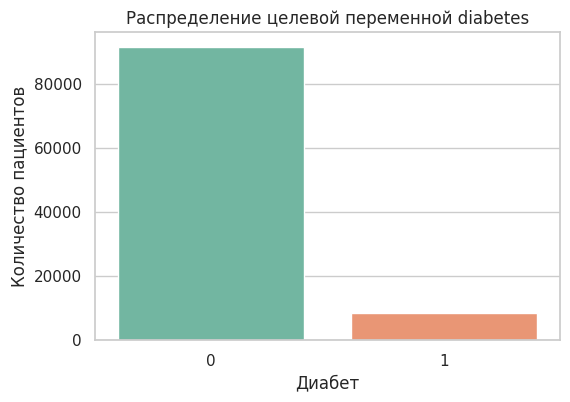

In [40]:
plt.figure(figsize=(6, 4))
sns.countplot(data=diabetes, x='diabetes', palette='Set2')
plt.title('Распределение целевой переменной diabetes')
plt.xlabel('Диабет')
plt.ylabel('Количество пациентов')
plt.show()

### Распределение числовых признаков

Построю гистограммы числовых признаков

In [41]:
num_cols = diabetes.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes'],
      dtype='object')

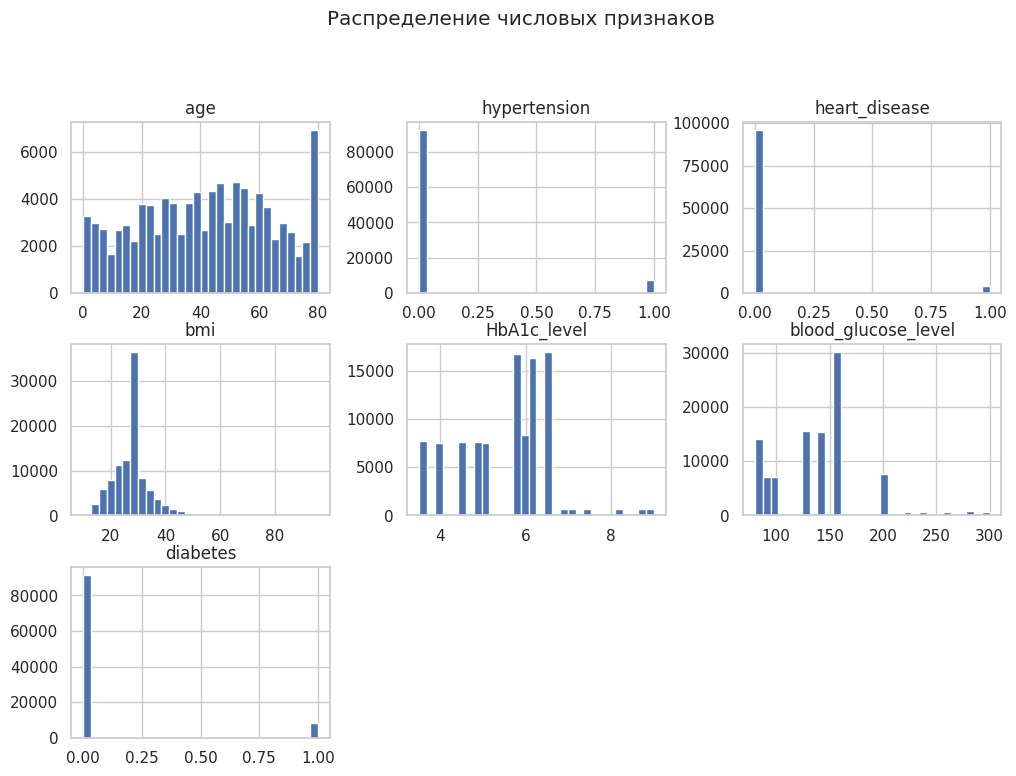

In [42]:
diabetes[num_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle('Распределение числовых признаков', y=1.02)
plt.show()

По гистограммам видно, что возраст распределен довольно широко, а признаки HbA1c_level и blood_glucose_level имеют несколько выраженных групп значений

### Парные диаграммы рассеяния

Датасет большой, поэтому для pairplot возьмем небольшую случайную выборку.

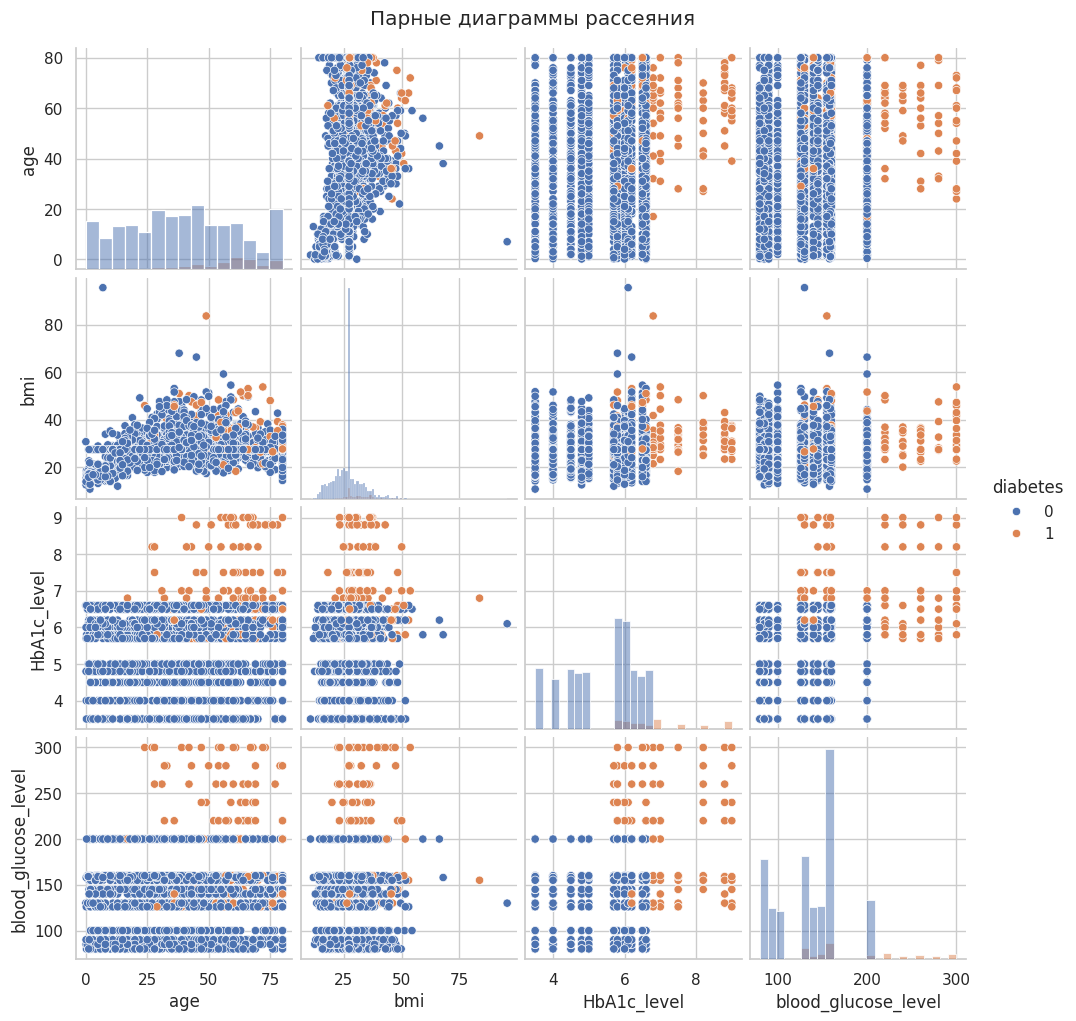

In [43]:
pair_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
sample_for_plot = diabetes[pair_cols].sample(2000, random_state=42)

sns.pairplot(sample_for_plot, hue='diabetes', diag_kind='hist')
plt.suptitle('Парные диаграммы рассеяния', y=1.02)
plt.show()

По диаграммам заметно, что у пациентов с диабетом чаще выше возраст, HbA1c и уровень глюкозы.

## Очистка данных и неинформативные признаки

В этом датасете нет отдельного ID-столбца. Проверю категорию Other в признаке gender

In [44]:
diabetes['gender'].value_counts()

,count
gender,
Female,58552
Male,41430
Other,18


In [45]:
diabetes = diabetes[diabetes['gender'] != 'Other']
diabetes.shape

(99982, 9)

## Пропущенные значения


In [46]:
diabetes.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [47]:
cols_with_null = diabetes.isnull().mean() * 100
cols_with_null = cols_with_null[cols_with_null > 0].sort_values(ascending=False)
cols_with_null

,0


Пропусков нет. Для отчета все равно построю карту пропусков

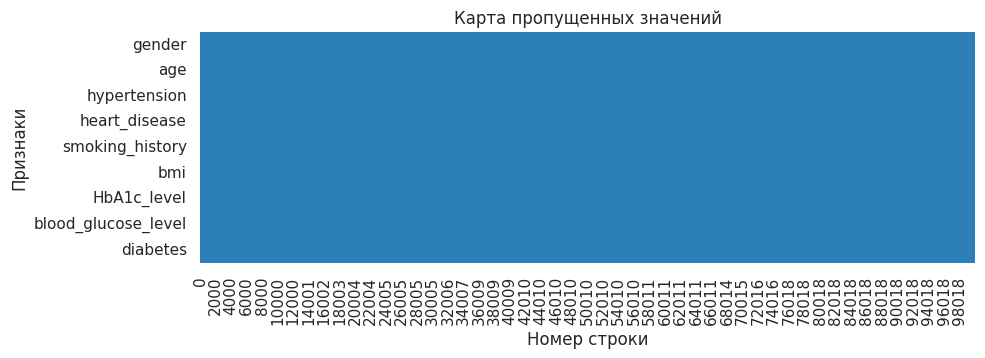

In [48]:
plt.figure(figsize=(10, 3))
sns.heatmap(diabetes.isnull().T, cbar=False, cmap=sns.color_palette(['#2c7fb8', '#fdae61']))
plt.title('Карта пропущенных значений')
plt.xlabel('Номер строки')
plt.ylabel('Признаки')
plt.show()

### Дубликаты

Проверю полные дубликаты

In [49]:
diabetes.duplicated().sum()

np.int64(3854)

Дубликаты есть. Тк идентификатора пациента нет, одинаковые строки могут повторяться

In [50]:
diabetes = diabetes.drop_duplicates()
diabetes.shape

(96128, 9)

### Выбросы
 выбросы методом межквартильного размаха

In [51]:
def outliers_iqr(data, feature):
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75)
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - 1.5 * iqr
    upper_bound = quartile_3 + 1.5 * iqr
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

In [52]:
for feature in ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']:
    outliers, cleaned = outliers_iqr(diabetes, feature)
    print(feature)
    print('Количество выбросов:', outliers.shape[0])
    print('Размер после очистки:', cleaned.shape)
    print()

age
Количество выбросов: 0
Размер после очистки: (96128, 9)

bmi
Количество выбросов: 5354
Размер после очистки: (90774, 9)

HbA1c_level
Количество выбросов: 1312
Размер после очистки: (94816, 9)

blood_glucose_level
Количество выбросов: 2031
Размер после очистки: (94097, 9)



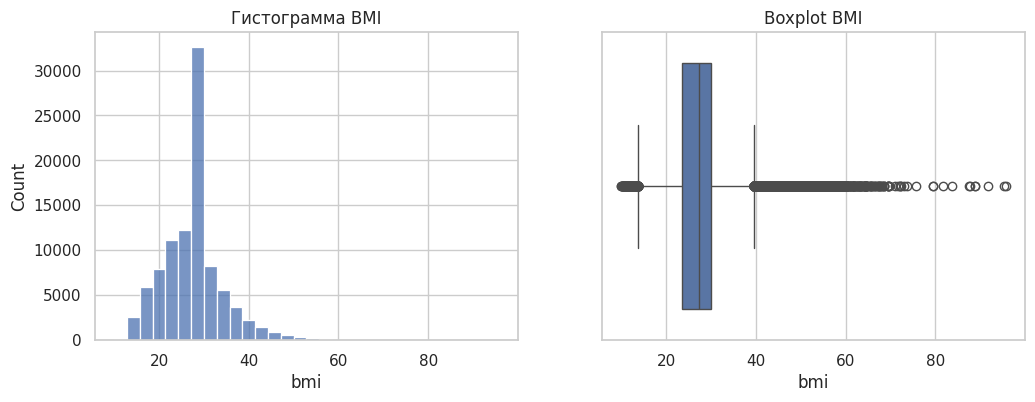

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(diabetes['bmi'], bins=30, ax=axes[0])
axes[0].set_title('Гистограмма BMI')
sns.boxplot(x=diabetes['bmi'], ax=axes[1])
axes[1].set_title('Boxplot BMI')
plt.show()

Высокий BMI и высокая глюкоза могут быть медицински важными значениями, а не ошибками. Удалять выбросы не буду

### Метод z-отклонений
логарифмированное распределение BMI.

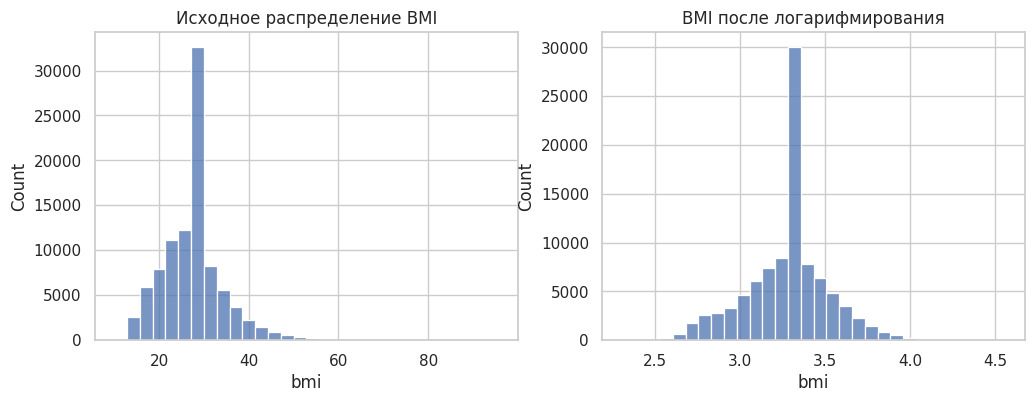

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(diabetes['bmi'], bins=30, ax=axes[0])
axes[0].set_title('Исходное распределение BMI')
sns.histplot(np.log(diabetes['bmi']), bins=30, ax=axes[1])
axes[1].set_title('BMI после логарифмирования')
plt.show()

In [55]:
def outliers_z_score(data, feature, log_scale=False, left=3, right=3):
    if log_scale:
        x = np.log(data[feature])
    else:
        x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - left * sigma
    upper_bound = mu + right * sigma
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

In [56]:
outliers, cleaned = outliers_z_score(diabetes, 'bmi', log_scale=True)
print('Количество выбросов:', outliers.shape[0])
print('Размер после очистки:', cleaned.shape)

Количество выбросов: 463
Размер после очистки: (95665, 9)


Выбросы оставлю, потому что для медицинской задачи они могут быть важными

## ОБРАБОТКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ


In [57]:
cat_cols = diabetes.select_dtypes(include='object').columns
cat_cols

Index(['gender', 'smoking_history'], dtype='object')

In [58]:
for col in cat_cols:
    print(col)
    print(diabetes[col].value_counts())
    print()

gender
gender
Female    56161
Male      39967
Name: count, dtype: int64

smoking_history
smoking_history
never          34395
No Info        32881
former          9299
current         9197
not current     6359
ever            3997
Name: count, dtype: int64



In [59]:
diabetes_encoded = diabetes.copy()

diabetes_encoded['gender'] = diabetes_encoded['gender'].map({'Female': 0, 'Male': 1})

diabetes_encoded['smoking_history'] = diabetes_encoded['smoking_history'].map({
    'No Info': 0,
    'never': 1,
    'former': 2,
    'current': 3,
    'not current': 4,
    'ever': 5
})

diabetes_encoded.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,1,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,1,27.32,5.7,158,0
3,0,36.0,0,0,3,23.45,5.0,155,0
4,1,76.0,1,1,3,20.14,4.8,155,0


In [60]:
diabetes_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96128 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96128 non-null  int64  
 1   age                  96128 non-null  float64
 2   hypertension         96128 non-null  int64  
 3   heart_disease        96128 non-null  int64  
 4   smoking_history      96128 non-null  int64  
 5   bmi                  96128 non-null  float64
 6   HbA1c_level          96128 non-null  float64
 7   blood_glucose_level  96128 non-null  int64  
 8   diabetes             96128 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 7.3 MB


## КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
матрица корреляций

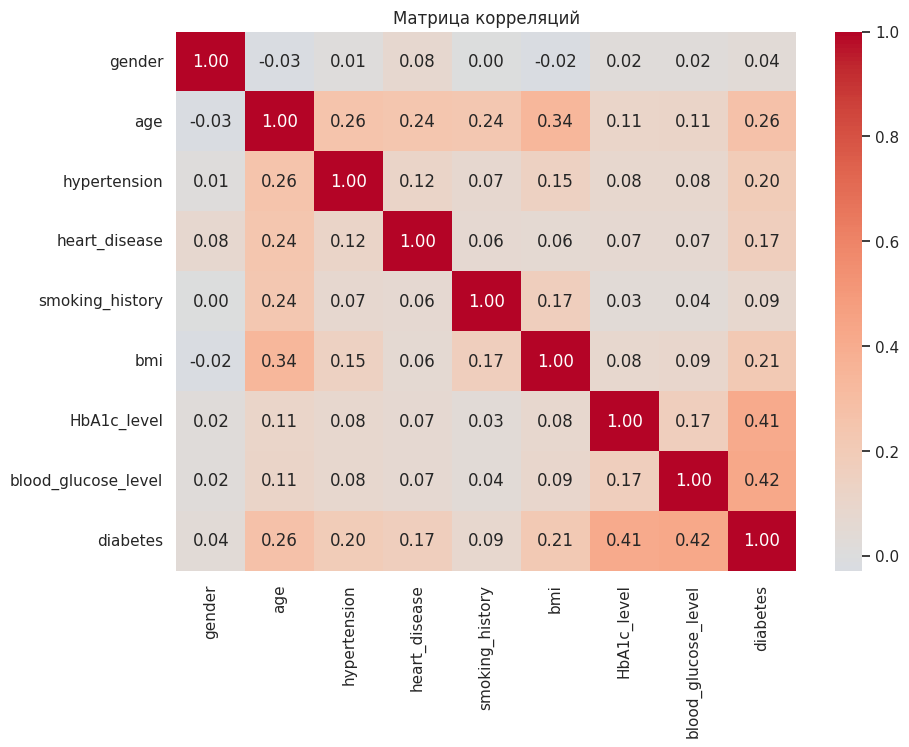

In [61]:
corr = diabetes_encoded.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляций')
plt.show()

In [62]:
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.8:
            high_corr.append([corr.columns[i], corr.columns[j], corr.iloc[i, j]])

pd.DataFrame(high_corr, columns=['Признак 1', 'Признак 2', 'Корреляция'])

,Признак 1,Признак 2,Корреляция


# СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ

Уровень значимости: 0.05.

In [63]:
alpha = 0.05

## Гипотеза 1: влияние гипертонии на диабет

H0: гипертония не связана с наличием диабета.  
H1: пациенты с гипертонией чаще имеют диабет.

In [64]:
table_hyp = pd.crosstab(diabetes['hypertension'], diabetes['diabetes'])
table_hyp

diabetes,0,1
hypertension,,
0,82271,6396
1,5375,2086


In [65]:
oddsratio, pvalue = stats.fisher_exact(table_hyp)
print(f'OR = {oddsratio:.3f}')
print(f'p-value = {pvalue:.5f}')

if pvalue < alpha:
    print('Нулевую гипотезу отклоняем.')
else:
    print('Нет оснований отклонить нулевую гипотезу.')

OR = 4.992
p-value = 0.00000
Нулевую гипотезу отклоняем.


**Вывод:** связь есть. У пациентов с гипертонией диабет встречается чаще

## Гипотеза 2: влияние заболеваний сердца на диабет

H0: заболевания сердца не связаны с наличием диабета.  
H1: пациенты с заболеваниями сердца чаще имеют диабет.

In [66]:
table_heart = pd.crosstab(diabetes['heart_disease'], diabetes['diabetes'])
table_heart

diabetes,0,1
heart_disease,,
0,84990,7215
1,2656,1267


In [67]:
oddsratio, pvalue = stats.fisher_exact(table_heart)
print(f'OR = {oddsratio:.3f}')
print(f'p-value = {pvalue:.5f}')

if pvalue < alpha:
    print('Нулевую гипотезу отклоняем.')
else:
    print('Нет оснований отклонить нулевую гипотезу.')

OR = 5.619
p-value = 0.00000
Нулевую гипотезу отклоняем.


**Вывод связь между заболеваниями сердца и диабетом статистически значима

## Гипотеза 3: различие возраста у пациентов с диабетом и без диабета

H0: возраст пациентов с диабетом и без диабета не отличается.  
H1: возраст отличается.

In [68]:
diabetes_yes_age = diabetes[diabetes['diabetes'] == 1]['age']
diabetes_no_age = diabetes[diabetes['diabetes'] == 0]['age']

print('Медиана возраста при diabetes=1:', diabetes_yes_age.median())
print('Медиана возраста при diabetes=0:', diabetes_no_age.median())

Медиана возраста при diabetes=1: 62.0
Медиана возраста при diabetes=0: 40.0


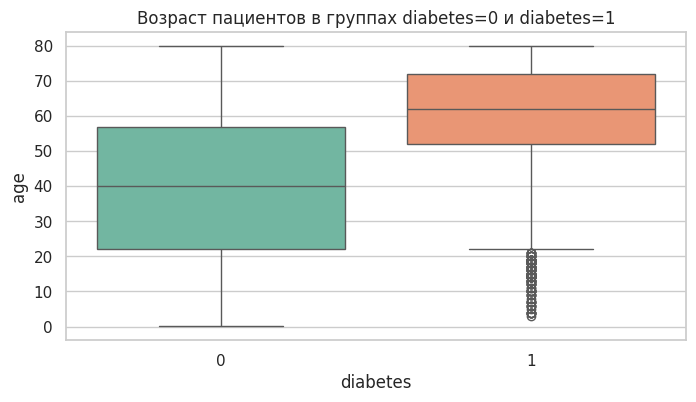

In [69]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=diabetes, x='diabetes', y='age', palette='Set2')
plt.title('Возраст пациентов в группах diabetes=0 и diabetes=1')
plt.show()

In [70]:
stat, pvalue = stats.mannwhitneyu(diabetes_yes_age, diabetes_no_age, alternative='two-sided')
print(f'U-statistic = {stat:.3f}')
print(f'p-value = {pvalue:.5f}')

if pvalue < alpha:
    print('Нулевую гипотезу отклоняем.')
else:
    print('Нет оснований отклонить нулевую гипотезу.')

U-statistic = 575228835.500
p-value = 0.00000
Нулевую гипотезу отклоняем.


Вывод: пациенты с диабетом в среднем старше

## Гипотеза 4: различие уровня HbA1c у пациентов с диабетом и без диабета

H0: уровень HbA1c не отличается между группами.  
H1: уровень HbA1c отличается.

In [71]:
diabetes_yes_hba1c = diabetes[diabetes['diabetes'] == 1]['HbA1c_level']
diabetes_no_hba1c = diabetes[diabetes['diabetes'] == 0]['HbA1c_level']

print('Медиана HbA1c при diabetes=1:', diabetes_yes_hba1c.median())
print('Медиана HbA1c при diabetes=0:', diabetes_no_hba1c.median())

Медиана HbA1c при diabetes=1: 6.6
Медиана HbA1c при diabetes=0: 5.8


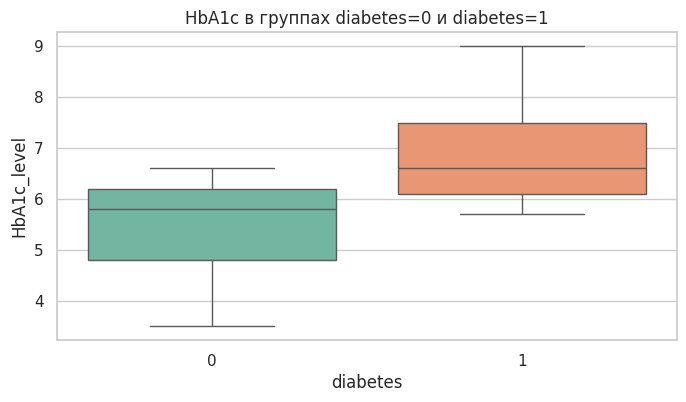

In [72]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=diabetes, x='diabetes', y='HbA1c_level', palette='Set2')
plt.title('HbA1c в группах diabetes=0 и diabetes=1')
plt.show()

In [73]:
stat, pvalue = stats.mannwhitneyu(diabetes_yes_hba1c, diabetes_no_hba1c, alternative='two-sided')
print(f'U-statistic = {stat:.3f}')
print(f'p-value = {pvalue:.5f}')

if pvalue < alpha:
    print('Нулевую гипотезу отклоняем.')
else:
    print('Нет оснований отклонить нулевую гипотезу.')

U-statistic = 623990620.500
p-value = 0.00000
Нулевую гипотезу отклоняем.


**Вывод:** HbA1c сильно связан с наличием диабета. Это логично, потому что показатель напрямую относится к уровню сахара за длительный период.

## Гипотеза 5: связь истории курения и диабета

H0: smoking_history не связан с диабетом.  
H1: связь между smoking_history и диабетом есть.

In [74]:
table_smoke = pd.crosstab(diabetes['smoking_history'], diabetes['diabetes'])
table_smoke

diabetes,0,1
smoking_history,,
No Info,31436,1445
current,8249,948
ever,3525,472
former,7709,1590
never,31058,3337
not current,5669,690


In [75]:
chi2, pvalue, dof, expected = stats.chi2_contingency(table_smoke)
print(f'chi2 = {chi2:.3f}')
print(f'p-value = {pvalue:.5f}')

if pvalue < alpha:
    print('Нулевую гипотезу отклоняем.')
else:
    print('Нет оснований отклонить нулевую гипотезу.')

chi2 = 1728.122
p-value = 0.00000
Нулевую гипотезу отклоняем.


Вывод:статистическая связь есть, но в этом признаке много значений No Info

# МАШИННОЕ ОБУЧЕНИЕ

задача бинарной классификации.

In [76]:
X = diabetes_encoded.drop('diabetes', axis=1)
y = diabetes_encoded['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Размер X_train:', X_train.shape)
print('Размер X_test:', X_test.shape)

Размер X_train: (76902, 8)
Размер X_test: (19226, 8)


In [77]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Доля объясненной дисперсии:
[0.22822472 0.13834924]
Суммарная объясненная дисперсия: 0.366573955451477


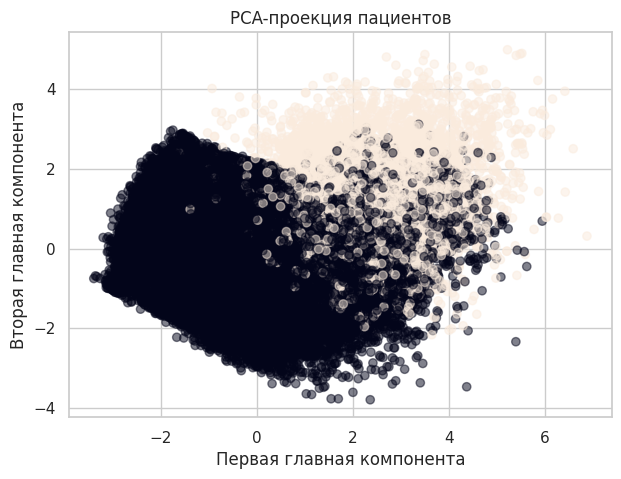

In [94]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Доля объясненной дисперсии:")
print(pca.explained_variance_ratio_)
print("Суммарная объясненная дисперсия:",
      pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7, 5))
plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    alpha=0.5
)
plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.title("PCA-проекция пациентов")
plt.show()

PCA уменьшает размерность признакового пространства, а также позволяет выявить скрытые зависимости между пациентами. Метод особенно перспективен для анализа многомерных рамановских спектров.

Объясненная дисперсия SVD:
[0.22822472 0.13834924]
Суммарная объясненная дисперсия: 0.36657395545147947


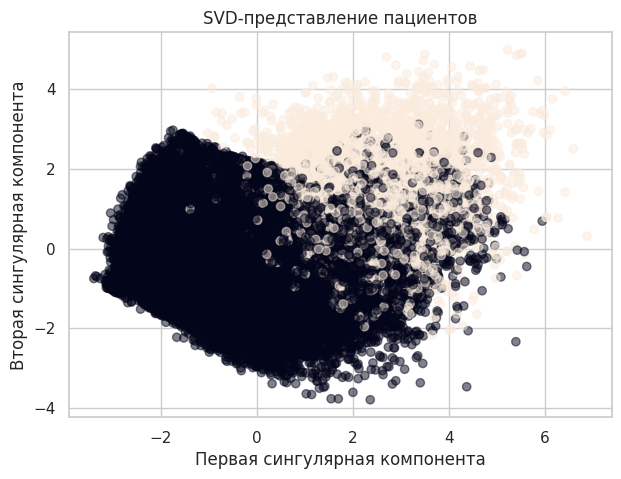

In [95]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_train_svd = svd.fit_transform(X_train_scaled)
X_test_svd = svd.transform(X_test_scaled)

print("Объясненная дисперсия SVD:")
print(svd.explained_variance_ratio_)
print("Суммарная объясненная дисперсия:",
      svd.explained_variance_ratio_.sum())

plt.figure(figsize=(7, 5))
plt.scatter(
    X_train_svd[:, 0],
    X_train_svd[:, 1],
    c=y_train,
    alpha=0.5
)
plt.xlabel("Первая сингулярная компонента")
plt.ylabel("Вторая сингулярная компонента")
plt.title("SVD-представление пациентов")
plt.show()

SVD представляет данные в виде ортогональных компонент. Метод может использоваться для подавления шума и выделения информативных признаков. Для рамановских спектров SVD особенно полезен, поскольку помогает отделить полезный сигнал (например, связанный с глюкозой и HbA1c) от фоновых колебаний и измерительного шума



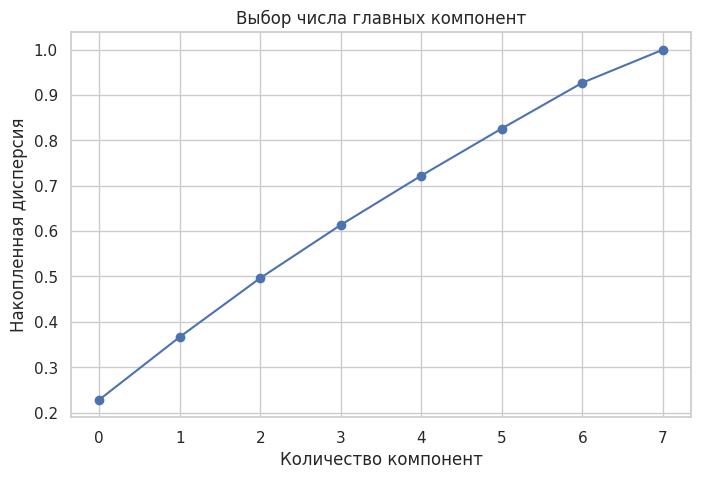

In [98]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca_full = PCA()
pca_full.fit(X_train_scaled)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel("Количество компонент")
plt.ylabel("Накопленная дисперсия")
plt.title("Выбор числа главных компонент")
plt.grid(True)
plt.show()


In [96]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import roc_auc_score


model_pca = LogisticRegression(

    max_iter=1000,

    class_weight="balanced",

    random_state=42

)

model_pca.fit(X_train_pca, y_train)

pred_proba = model_pca.predict_proba(X_test_pca)[:, 1]

print("ROC-AUC после PCA:",

      roc_auc_score(y_test, pred_proba))

ROC-AUC после PCA: 0.9322369704495798


Выполнила снижение размерности, а также проверила как оно влияет на качество классификации

## Метрики качества

Так как классы несбалансированы, смотрю не только accuracy, но и recall, F1, ROC AUC, PR AUC и specificity.

In [78]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)


def get_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced accuracy': balanced_accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC AUC': roc_auc_score(y_true, y_proba),
        'PR AUC': average_precision_score(y_true, y_proba),
        'Specificity': specificity_score(y_true, y_pred)
    }

In [79]:
def train_and_test_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return get_metrics(y_test, y_pred, y_proba), y_pred, y_proba

## Сравнение алгоритмов

Сравню логистическую регрессию, дерево решений и KNN

In [80]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'KNeighbors': KNeighborsClassifier(n_neighbors=7)
}

results = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    if name in ['LogisticRegression', 'KNeighbors']:
        metrics, y_pred, y_proba = train_and_test_model(model, X_train_scaled, X_test_scaled, y_train, y_test)
    else:
        metrics, y_pred, y_proba = train_and_test_model(model, X_train, X_test, y_train, y_test)
    results[name] = metrics
    predictions[name] = y_pred
    probabilities[name] = y_proba

metrics_df = pd.DataFrame(results).T.round(4)
metrics_df

,Accuracy,Balanced accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Specificity
LogisticRegression,0.8848,0.8772,0.4252,0.8679,0.5708,0.9593,0.8109,0.8865
DecisionTree,0.8572,0.8874,0.3746,0.9239,0.5331,0.9598,0.7878,0.8508
KNeighbors,0.9597,0.8022,0.9009,0.6108,0.7280,0.9145,0.7610,0.9935


У KNN высокая accuracy, но recall ниже, чем у логистической регрессии и дерева. Для медицинской задачи это важно, потому что пропускать пациентов с диабетом плохо.

## Матрицы ошибок

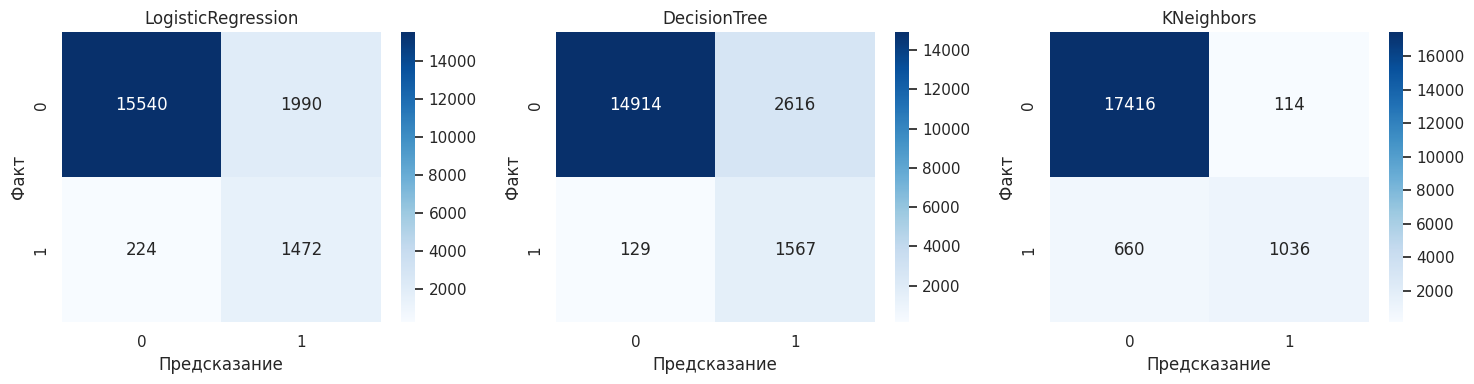

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, models.keys()):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Факт')

plt.tight_layout()
plt.show()

## ROC- и PR-кривые

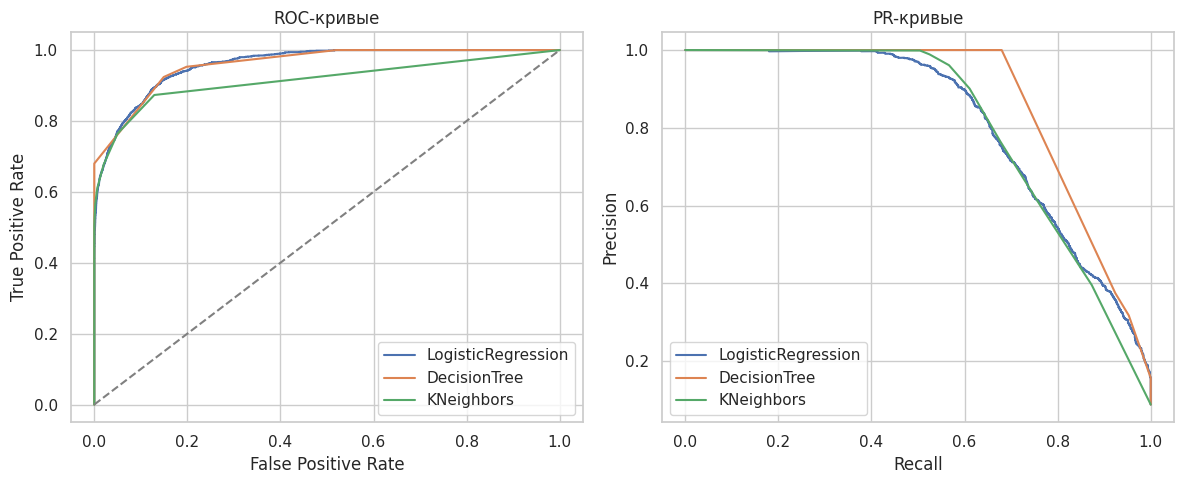

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    axes[0].plot(fpr, tpr, label=name)

axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[0].set_title('ROC-кривые')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

for name in models.keys():
    precision, recall, _ = precision_recall_curve(y_test, probabilities[name])
    axes[1].plot(recall, precision, label=name)

axes[1].set_title('PR-кривые')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

In [83]:
for metric in metrics_df.columns:
    print(metric)
    print(metrics_df[metric].sort_values(ascending=False))
    print()

Accuracy
KNeighbors            0.9597
LogisticRegression    0.8848
DecisionTree          0.8572
Name: Accuracy, dtype: float64

Balanced accuracy
DecisionTree          0.8874
LogisticRegression    0.8772
KNeighbors            0.8022
Name: Balanced accuracy, dtype: float64

Precision
KNeighbors            0.9009
LogisticRegression    0.4252
DecisionTree          0.3746
Name: Precision, dtype: float64

Recall
DecisionTree          0.9239
LogisticRegression    0.8679
KNeighbors            0.6108
Name: Recall, dtype: float64

F1
KNeighbors            0.7280
LogisticRegression    0.5708
DecisionTree          0.5331
Name: F1, dtype: float64

ROC AUC
DecisionTree          0.9598
LogisticRegression    0.9593
KNeighbors            0.9145
Name: ROC AUC, dtype: float64

PR AUC
LogisticRegression    0.8109
DecisionTree          0.7878
KNeighbors            0.7610
Name: PR AUC, dtype: float64

Specificity
KNeighbors            0.9935
LogisticRegression    0.8865
DecisionTree          0.8508
Name: S

По ROC AUC и PR AUC лучше всего выглядит логистическая регрессия. Дерево решений дает самый высокий recall, но делает больше ложных срабатываний.

## Подбор гиперпараметров

параметр C для логистической регрессии.

In [84]:
param_grid = {'C': [0.01, 0.1, 1, 10]}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=5
)

grid_search.fit(X_train_scaled, y_train)

print('Лучшие параметры:', grid_search.best_params_)
print('Лучший ROC AUC на кросс-валидации:', round(grid_search.best_score_, 4))

Лучшие параметры: {'C': 0.01}
Лучший ROC AUC на кросс-валидации: 0.9622


In [85]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

best_metrics = pd.DataFrame(
    get_metrics(y_test, y_pred_best, y_proba_best),
    index=['LogisticRegression после подбора']
).round(4)

best_metrics

,Accuracy,Balanced accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Specificity
LogisticRegression после подбора,0.8856,0.8789,0.4271,0.8709,0.5731,0.9593,0.8104,0.887


## Вклад признаков в предсказание

Абсолютные значения коэффициентов.

In [86]:
coef = pd.Series(
    np.abs(best_model.coef_[0]),
    index=X.columns
).sort_values(ascending=False)

coef

,0
HbA1c_level,2.153552
blood_glucose_level,1.240158
age,1.108942
bmi,0.633926
hypertension,0.216508
gender,0.152768
heart_disease,0.149384
smoking_history,0.136916


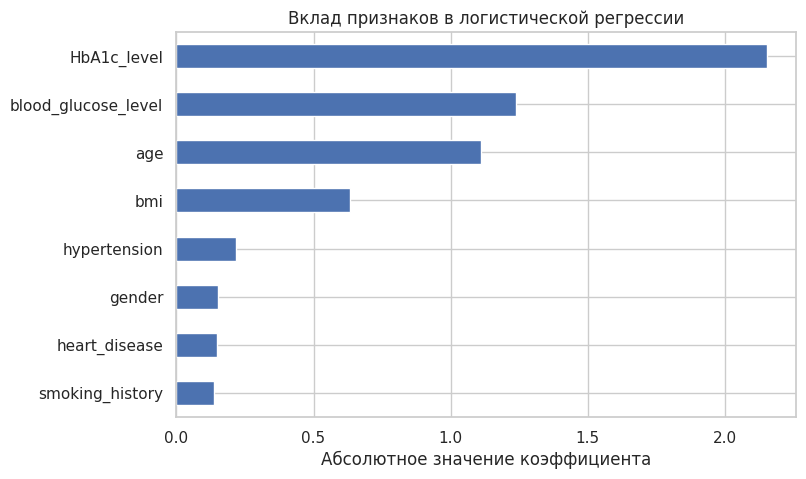

In [87]:
plt.figure(figsize=(8, 5))
coef.sort_values().plot(kind='barh')
plt.title('Вклад признаков в логистической регрессии')
plt.xlabel('Абсолютное значение коэффициента')
plt.show()

In [88]:
tree_model = models['DecisionTree']
tree_importance = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

tree_importance

,0
HbA1c_level,0.521811
blood_glucose_level,0.355213
age,0.106222
bmi,0.016754
heart_disease,0.000000
hypertension,0.000000
gender,0.000000
smoking_history,0.000000


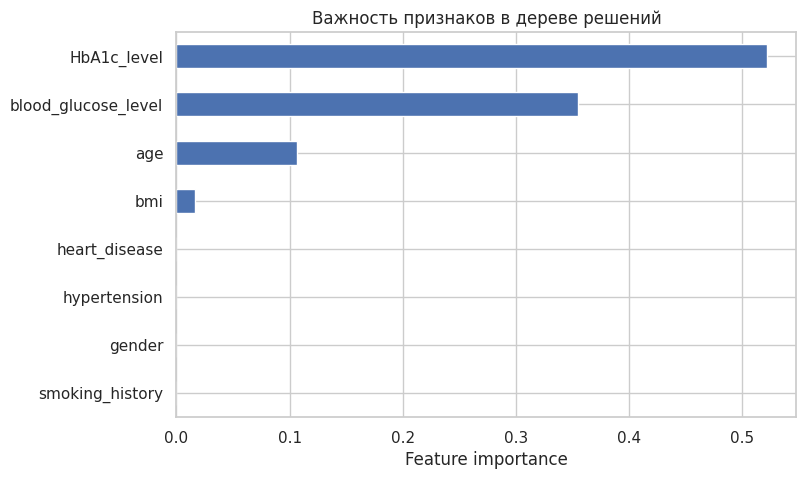

In [89]:
plt.figure(figsize=(8, 5))
tree_importance.sort_values().plot(kind='barh')
plt.title('Важность признаков в дереве решений')
plt.xlabel('Feature importance')
plt.show()

Я использовала медицинский датасет для предсказания диабета.
Получилось, что в исходных данных 100000 наблюдений и 9 признаков,
пропусков нет, но были полные дубликаты, которые удалила, классы несбалансированы, тк пациентов без диабета больше. Статистические тесты показали связь диабета с гипертонией, болезнями сердца, возрастом, HbA1c и историей курения. Самые важные признаки для модели: HbA1c_level, blood_glucose_level, age и bmi. Среди рассмотренных моделей наиболее удачно выглядит логистическая регрессия после подбора параметра C.
Для медицинского прогноза важны recall, balanced accuracy, ROC AUC и PR AUC, потому что нужно находить пациентов с риском диабета